# eICU Ventilator Weaning Prediction with Trajectory Modeling
Analysis of P/F ratio trajectory features for predicting successful extubation

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import os
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

sys.path.append(os.path.abspath('../../../'))
from traj_features.backends.bootstrap import BootstrapTrajPS, BootstrapConfig
from traj_features.backends.bayes.classify import pos_flags_from_traj

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Imports successful")

WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


✓ Imports successful


## Load Data

In [2]:
# Load trajectory probabilities (already merged with prediction dataset)
dataset = pd.read_csv('../../../results/eicu/ventilator/ventilator_trajectory_probs.csv')
print(f"✓ Loaded merged dataset: {len(dataset):,} samples")
print(f"  Unique patients: {dataset['stay_id'].nunique():,}")
print(f"  Outcome rate: {dataset['target_weaning_success'].mean():.1%}")
print(f"  Columns: {len(dataset.columns)}")

✓ Loaded merged dataset: 51,528 samples
  Unique patients: 12,340
  Outcome rate: 7.4%
  Columns: 67


In [3]:
# Load P/F ratio time series for summary statistics
pf_ts = pd.read_csv('../../../results/eicu/ventilator/pf_ratio_timeseries.csv')
print(f"✓ Loaded P/F ratio time series: {len(pf_ts):,} measurements")
print(f"  Patients: {pf_ts['stay_id'].nunique():,}")

✓ Loaded P/F ratio time series: 136,402 measurements
  Patients: 12,340


In [4]:
# Bootstrap trajectory probabilities (cached)
bootstrap_path = '../../../results/eicu/ventilator/ventilator_trajectory_probs_bootstrap.csv'
label_map = {'nonprogression': 'prolonged_nonprogression', 'linear': 'linear_decline', 'nonlinear': 'nonlinear'}

if os.path.exists(bootstrap_path):
    pf_boot = pd.read_csv(bootstrap_path)
else:
    traj_input = pf_ts[['stay_id', 'time_days', 'time_day', 'pf_ratio']].copy()
    traj_input = traj_input.rename(columns={'stay_id': 'patientid', 'pf_ratio': 'lab_value'})
    traj_input = traj_input.dropna(subset=['lab_value']).sort_values(by=['patientid', 'time_days'])
    model = BootstrapTrajPS(BootstrapConfig(
        window_years=3.0,
        n_bootstrap=200,
        smoothing=None,
        min_points_per_window=4,
        grid_freq=2,
        flat_thr=10.0,
        decline_thr=30.0,
        nonlinear_gap=20.0,
        pids='patientid',
        values='lab_value',
        time_col='time_days',
        windowing_col='time_day',
        n_jobs=-1,
        traj_types=('prolonged_nonprogression', 'linear_decline', 'nonlinear'),
        class_func=pos_flags_from_traj,
        label_map=label_map,
        progressbar=False
    ))
    pf_boot = model.embed(traj_input)
    pf_boot = pf_boot.rename(columns={'patientid': 'stay_id'})
    pf_boot.to_csv(bootstrap_path, index=False)

if 'patientid' in pf_boot.columns:
    pf_boot = pf_boot.rename(columns={'patientid': 'stay_id'})

pf_boot = pf_boot.rename(columns={
    'trajtype_prolonged_nonprogression_prob': 'prob_stable_boot',
    'trajtype_linear_decline_prob': 'prob_gradual_improvement_boot',
    'trajtype_nonlinear_prob': 'prob_rapid_improvement_boot',
})

dataset = dataset.merge(
    pf_boot[['stay_id', 'time_day', 'prob_stable_boot', 'prob_gradual_improvement_boot', 'prob_rapid_improvement_boot']],
    on=['stay_id', 'time_day'],
    how='left'
)

print('✓ Added bootstrap trajectory probabilities')

KeyboardInterrupt: 

## Feature Engineering

In [ ]:
# Create 3-day summary statistics (matching lookback window)
LOOKBACK_DAYS = 3

summary_list = []
for patient_id, group_df in pf_ts.groupby('stay_id'):
    group_df = group_df.sort_values('time_days')
    
    for current_day in group_df['time_day'].unique():
        window_start = current_day - LOOKBACK_DAYS
        window_data = group_df[group_df['time_day'].between(window_start, current_day, inclusive='both')]
        
        if len(window_data) > 0:
            summary_list.append({
                'stay_id': patient_id,
                'time_day': current_day,
                'pf_mean_3d': window_data['pf_ratio'].mean(),
                'pf_max_3d': window_data['pf_ratio'].max(),
                'pf_min_3d': window_data['pf_ratio'].min(),
                'pf_change_3d': window_data['pf_ratio'].iloc[-1] - window_data['pf_ratio'].iloc[0],
                'pf_trend_3d': np.polyfit(window_data['time_days'], window_data['pf_ratio'], 1)[0] if len(window_data) > 1 else 0,
                'pf_std_3d': window_data['pf_ratio'].std() if len(window_data) > 1 else 0
            })

pf_summary = pd.DataFrame(summary_list)
print(f"✓ Created 3-day P/F ratio summary: {len(pf_summary):,} timepoints")

✓ Created 3-day P/F ratio summary: 71,787 timepoints


## Merge Features

In [ ]:
dataset.columns

Index(['stay_id', 'time_day', 'max_BUN', 'max_FiO2', 'max_bicarbonate',
       'max_chloride', 'max_creatinine', 'max_glucose', 'max_pH', 'max_paCO2',
       'max_paO2', 'max_potassium', 'max_sodium', 'mean_BUN', 'mean_FiO2',
       'mean_bicarbonate', 'mean_chloride', 'mean_creatinine', 'mean_glucose',
       'mean_pH', 'mean_paCO2', 'mean_paO2', 'mean_potassium', 'mean_sodium',
       'min_BUN', 'min_FiO2', 'min_bicarbonate', 'min_chloride',
       'min_creatinine', 'min_glucose', 'min_pH', 'min_paCO2', 'min_paO2',
       'min_potassium', 'min_sodium', 'heart_rate_min', 'heart_rate_max',
       'heart_rate_mean', 'respiratory_rate_min', 'respiratory_rate_max',
       'respiratory_rate_mean', 'o2_sat_min', 'o2_sat_max', 'o2_sat_mean',
       'systolic_min', 'systolic_max', 'systolic_mean', 'diastolic_min',
       'diastolic_max', 'diastolic_mean', 'mean_bp_min', 'mean_bp_max',
       'mean_bp_mean', 'pf_ratio_min', 'pf_ratio_max', 'pf_ratio_mean', 'age',
       'gender', 'hospital_exp

In [ ]:
# Add derived trajectory feature
dataset['prob_improving'] = dataset['prob_gradual_improvement'] + dataset['prob_rapid_improvement']
if {'prob_gradual_improvement_boot', 'prob_rapid_improvement_boot'}.issubset(dataset.columns):
    dataset['prob_improving_boot'] = dataset['prob_gradual_improvement_boot'] + dataset['prob_rapid_improvement_boot']

# Merge summary statistics
dataset = dataset.merge(
    pf_summary,
    on=['stay_id', 'time_day'],
    how='left'
 )

print(f"✓ Merged summary statistics: {len(dataset):,} samples, {len(dataset.columns)} columns")
print(f"\nMissing trajectory probabilities: {dataset['prob_stable'].isna().sum():,} ({100*dataset['prob_stable'].isna().mean():.1f}%)")

✓ Merged summary statistics: 51,528 samples, 74 columns

Missing trajectory probabilities: 24,014 (46.6%)


In [ ]:
# Handle missing values
# Forward-fill trajectory probs within patient (up to 2 days)
traj_cols = [c for c in ['prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement', 'prob_improving',
                         'prob_stable_boot', 'prob_gradual_improvement_boot', 'prob_rapid_improvement_boot', 'prob_improving_boot']
            if c in dataset.columns]
dataset[traj_cols] = dataset.groupby('stay_id')[traj_cols].ffill(limit=2)

summary_cols = ['pf_mean_3d', 'pf_max_3d', 'pf_min_3d', 'pf_change_3d', 'pf_trend_3d', 'pf_std_3d']

print(f"✓ Handled missing values")

✓ Handled missing values


## Define Feature Sets

In [ ]:
traj_bayes = ['prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement', 'prob_improving']
traj_boot = [c for c in ['prob_stable_boot', 'prob_gradual_improvement_boot', 'prob_rapid_improvement_boot', 'prob_improving_boot'] if c in dataset.columns]
summary_cols = ['pf_mean_3d', 'pf_max_3d', 'pf_min_3d', 'pf_change_3d', 'pf_trend_3d', 'pf_std_3d']
static_cols = ['age', 'gender', 'baseline_pf_ratio']

# Dynamic features (labs and vitals)
labs = ['max_BUN', 'max_FiO2', 'max_bicarbonate', 'max_chloride', 
        'max_creatinine', 'max_glucose', 'max_pH', 'max_paCO2', 'max_paO2',
        'max_potassium', 'max_sodium',
        'mean_BUN', 'mean_FiO2', 'mean_bicarbonate', 'mean_chloride', 
        'mean_creatinine', 'mean_glucose', 'mean_pH', 'mean_paCO2', 'mean_paO2',
        'mean_potassium', 'mean_sodium',
        'min_BUN', 'min_FiO2', 'min_bicarbonate', 'min_chloride', 
        'min_creatinine', 'min_glucose', 'min_pH', 'min_paCO2', 'min_paO2',
        'min_potassium', 'min_sodium']

vitals = ['heart_rate_min', 'heart_rate_max', 'heart_rate_mean',
          'respiratory_rate_min', 'respiratory_rate_max', 'respiratory_rate_mean',
          'o2_saturation_min', 'o2_saturation_max', 'o2_saturation_mean',
          'systolic_bp_min', 'systolic_bp_max', 'systolic_bp_mean',
          'diastolic_bp_min', 'diastolic_bp_max', 'diastolic_bp_mean',
          'mean_bp_min', 'mean_bp_max', 'mean_bp_mean',
          'temperature_min', 'temperature_max', 'temperature_mean']

dynamic_cols = labs + vitals
static_dynamic_cols = static_cols + dynamic_cols

feature_sets = {
    'Trajectory Only': traj_bayes,
    'Summary Only': summary_cols,
    'Static Only': static_cols,
    'Trajectory + Summary': traj_bayes + summary_cols,
    'Trajectory + Static': traj_bayes + static_cols,
    'Summary + Static': summary_cols + static_cols,
    'Trajectory + Summary + Static': traj_bayes + summary_cols + static_cols,
    'Trajectory Only (Bootstrap)': traj_boot,
    'Trajectory + Summary (Bootstrap)': traj_boot + summary_cols,
    'Trajectory + Static (Bootstrap)': traj_boot + static_cols,
    'Trajectory + Summary + Static (Bootstrap)': traj_boot + summary_cols + static_cols,
}

# Filter feature sets to remove unavailable columns and add dynamic combinations
for set_name, cols in list(feature_sets.items()):
    available = [c for c in cols if c in dataset.columns]
    removed = [c for c in cols if c not in dataset.columns]
    if removed:
        print(f"Feature set '{set_name}': removed {len(removed)} missing columns: {removed}")
    feature_sets[set_name] = available

if len(dynamic_cols) > 0:
    feature_sets['Static + Dynamic'] = [c for c in static_dynamic_cols if c in dataset.columns]
    feature_sets['Static + Dynamic + Trajectory'] = [c for c in static_dynamic_cols + traj_bayes if c in dataset.columns]
    feature_sets['Static + Dynamic + Trajectory (Bootstrap)'] = [c for c in static_dynamic_cols + traj_boot if c in dataset.columns]
    feature_sets['Static + Dynamic + Summary'] = [c for c in static_dynamic_cols + summary_cols if c in dataset.columns]
    feature_sets['Static + Dynamic + Summary + Trajectory'] = [c for c in static_dynamic_cols + summary_cols + traj_bayes if c in dataset.columns]
    feature_sets['Static + Dynamic + Summary + Trajectory (Bootstrap)'] = [c for c in static_dynamic_cols + summary_cols + traj_boot if c in dataset.columns]

for name, cols in feature_sets.items():
    print(f'{name}: {len(cols)} features')

Feature Sets:
  Trajectory Only                         :   4 features
  Summary Only                            :   6 features
  Static Only                             :   3 features
  Trajectory + Summary                    :  10 features
  Trajectory + Static                     :   7 features
  Summary + Static                        :   9 features
  Trajectory + Summary + Static           :  13 features
  Static + Dynamic                        :  54 features
  Trajectory + Static + Dynamic           :  58 features
  Summary + Static + Dynamic              :  60 features
  Trajectory + Summary + Static + Dynamic :  64 features


## Train Models

In [ ]:
# Encode gender
dataset['gender'] = dataset['gender'].map({'Male': 1, 'Female': 0})

# Prepare for modeling
dataset_clean = dataset.dropna(subset=['target_weaning_success'])
y = dataset_clean['target_weaning_success']
groups = dataset_clean['stay_id']

print(f"Dataset: {len(y):,} samples, {y.sum():,} events ({100*y.mean():.1f}%)")
print(f"Unique patients: {groups.nunique():,}")

Dataset: 51,528 samples, 3,804 events (7.4%)
Unique patients: 12,340


In [10]:
traj_cols = ['prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement', 'prob_improving']
summary_cols = ['pf_mean_3d', 'pf_max_3d', 'pf_min_3d', 'pf_change_3d', 'pf_trend_3d', 'pf_std_3d']

In [11]:
# Define models to compare
models_to_evaluate = {
    'XGBoost': lambda pos_weight, seed: XGBClassifier(
        n_estimators=100, 
        max_depth=3, 
        learning_rate=0.1,
        scale_pos_weight=pos_weight,
        random_state=seed,
        eval_metric='logloss'
    ),
    'Logistic Regression': lambda pos_weight, seed: LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=seed,
        solver='lbfgs'
    ),
    'Random Forest': lambda pos_weight, seed: RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        random_state=seed,
        n_jobs=4
    ),
    'Gradient Boosting': lambda pos_weight, seed: HistGradientBoostingClassifier(
        max_iter=100,
        max_depth=3,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=seed
    )
}

# Cross-validation
n_repeats = 10
n_folds = 5
results = {model_name: {} for model_name in models_to_evaluate.keys()}

print(f"\nTraining {n_repeats}-Repeat {n_folds}-Fold CV with {len(models_to_evaluate)} models:\n")

for model_name, model_fn in models_to_evaluate.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print('='*60)

    dataset_model = dataset_clean.copy()
    # zfill traj and summary features for none-boosting models
    if model_name not in ['XGBoost', 'Gradient Boosting']:
        dataset_model[traj_cols] = dataset_model[traj_cols].fillna(0)
        dataset_model[summary_cols] = dataset_model[summary_cols].fillna(0)
        
    
    for feature_set_name, feature_cols in feature_sets.items():
        print(f"{feature_set_name}...")
        
        fold_metrics = {'roc_auc': [], 'avg_precision': [], 'y_true': [], 'y_pred': []}
        
        for repeat in range(n_repeats):
            # Shuffle dataset for this repeat to get different fold randomizations
            shuffle_idx = np.random.RandomState(seed=920+repeat).permutation(len(dataset_model))
            dataset_repeat = dataset_model.iloc[shuffle_idx].reset_index(drop=True)
            y_repeat = y.iloc[shuffle_idx].reset_index(drop=True)
            groups_repeat = groups.iloc[shuffle_idx].reset_index(drop=True)
            
            gkf = GroupKFold(n_splits=n_folds)
            
            for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(dataset_repeat, y_repeat, groups_repeat)):
                X_train = dataset_repeat.iloc[train_idx][feature_cols]
                X_test = dataset_repeat.iloc[test_idx][feature_cols]
                y_train = y_repeat.iloc[train_idx]
                y_test = y_repeat.iloc[test_idx]
                
                if model_name not in ['XGBoost', 'Gradient Boosting']:
                    # Impute missing values using training data
                    imputer = SimpleImputer(strategy='median')
                    X_train_imputed = imputer.fit_transform(X_train)
                    X_test_imputed = imputer.transform(X_test)
                
                else:
                    # For boosting models, we can pass NaNs directly
                    X_train_imputed = X_train
                    X_test_imputed = X_test

                # Scale features
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_imputed)
                X_test_scaled = scaler.transform(X_test_imputed)
                
                # Train model
                scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
                model = model_fn(scale_pos_weight, 920+repeat)
                model.fit(X_train_scaled, y_train)
                
                # Predict
                y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
                
                # Metrics
                fold_metrics['roc_auc'].append(roc_auc_score(y_test, y_pred_proba))
                fold_metrics['avg_precision'].append(average_precision_score(y_test, y_pred_proba))
                fold_metrics['y_true'].extend(y_test)
                fold_metrics['y_pred'].extend(y_pred_proba)
        
        results[model_name][feature_set_name] = fold_metrics
        print(f"  AUROC: {np.mean(fold_metrics['roc_auc']):.3f} ± {np.std(fold_metrics['roc_auc']):.3f}")
        print(f"  AUPR:  {np.mean(fold_metrics['avg_precision']):.3f} ± {np.std(fold_metrics['avg_precision']):.3f}\n")


Training 10-Repeat 5-Fold CV with 4 models:


Model: XGBoost
Trajectory Only...
  AUROC: 0.671 ± 0.007
  AUPR:  0.119 ± 0.005

Summary Only...
  AUROC: 0.716 ± 0.008
  AUPR:  0.172 ± 0.010

Static Only...
  AUROC: 0.668 ± 0.011
  AUPR:  0.134 ± 0.009

Trajectory + Summary...
  AUROC: 0.740 ± 0.008
  AUPR:  0.187 ± 0.010

Trajectory + Static...
  AUROC: 0.752 ± 0.007
  AUPR:  0.194 ± 0.016

Summary + Static...
  AUROC: 0.773 ± 0.010
  AUPR:  0.232 ± 0.018

Trajectory + Summary + Static...
  AUROC: 0.788 ± 0.008
  AUPR:  0.250 ± 0.016

Static + Dynamic...
  AUROC: 0.783 ± 0.004
  AUPR:  0.263 ± 0.012

Trajectory + Static + Dynamic...
  AUROC: 0.796 ± 0.006
  AUPR:  0.284 ± 0.015

Summary + Static + Dynamic...
  AUROC: 0.800 ± 0.004
  AUPR:  0.286 ± 0.010

Trajectory + Summary + Static + Dynamic...
  AUROC: 0.805 ± 0.006
  AUPR:  0.297 ± 0.014


Model: Logistic Regression
Trajectory Only...
  AUROC: 0.654 ± 0.009
  AUPR:  0.116 ± 0.006

Summary Only...
  AUROC: 0.547 ± 0.005
  AUPR:  0.1

## Visualize Results

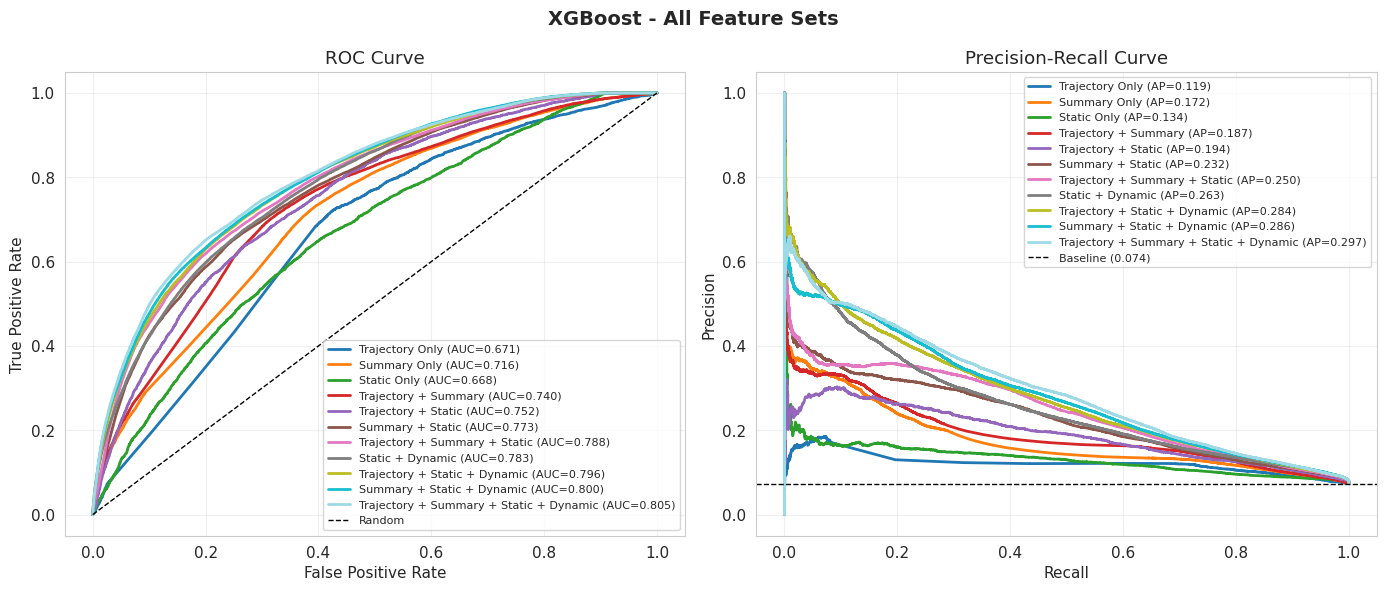

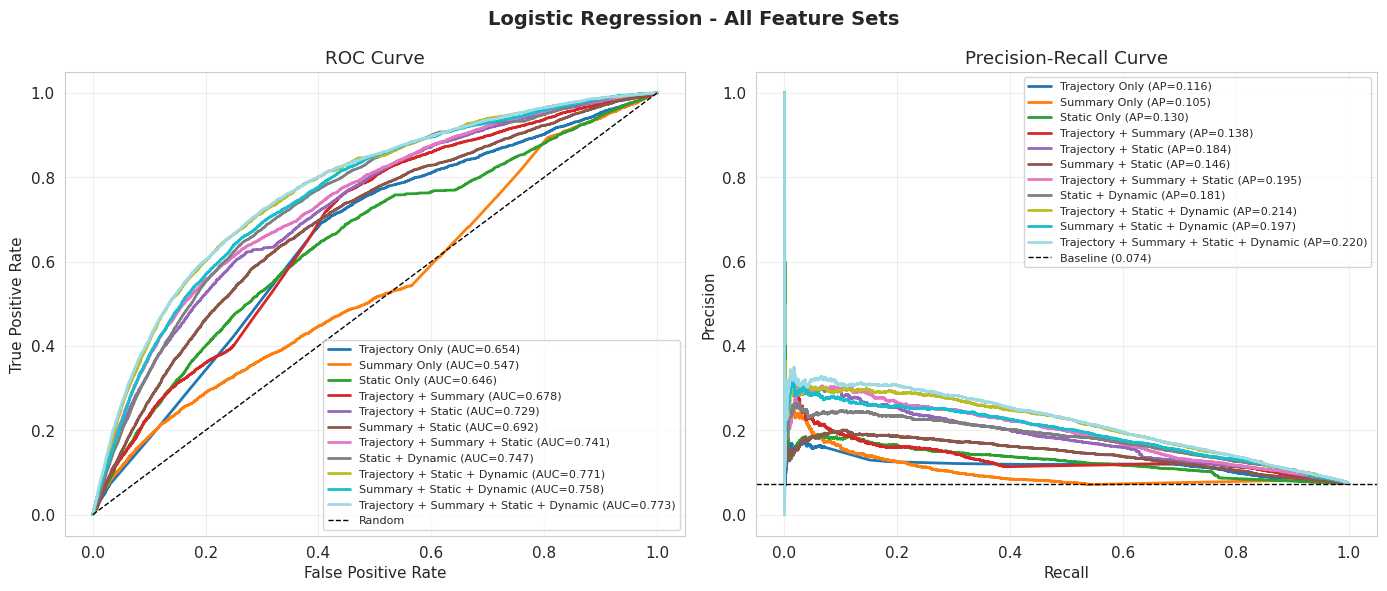

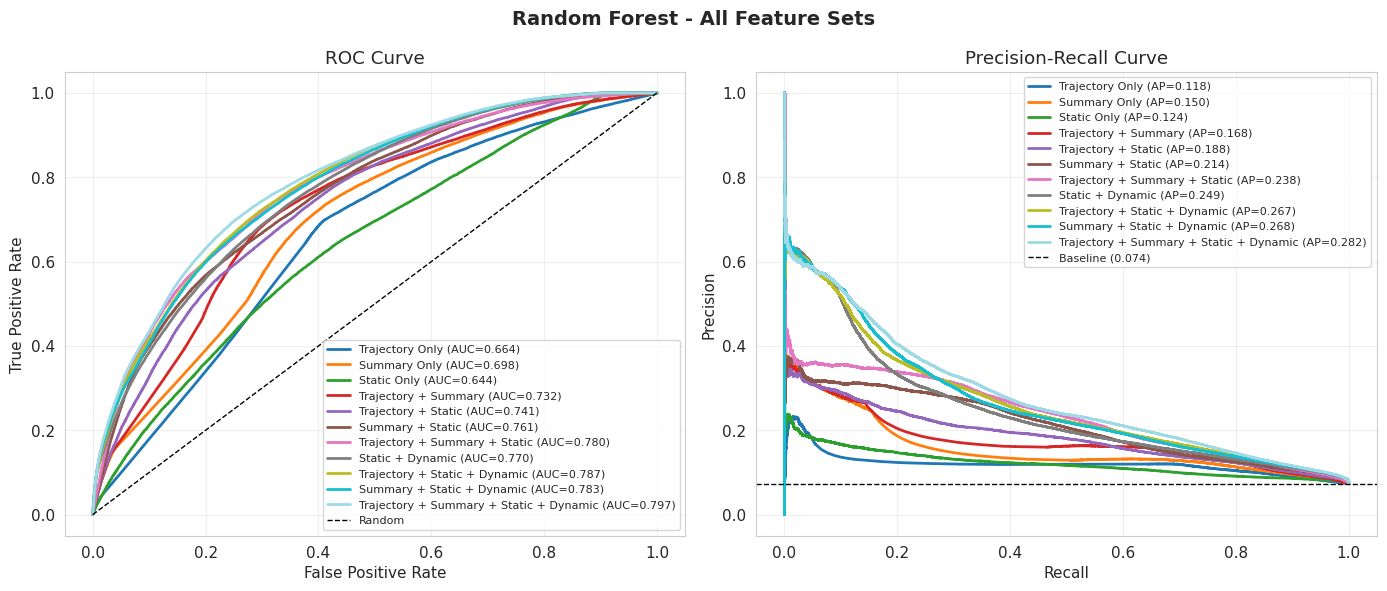

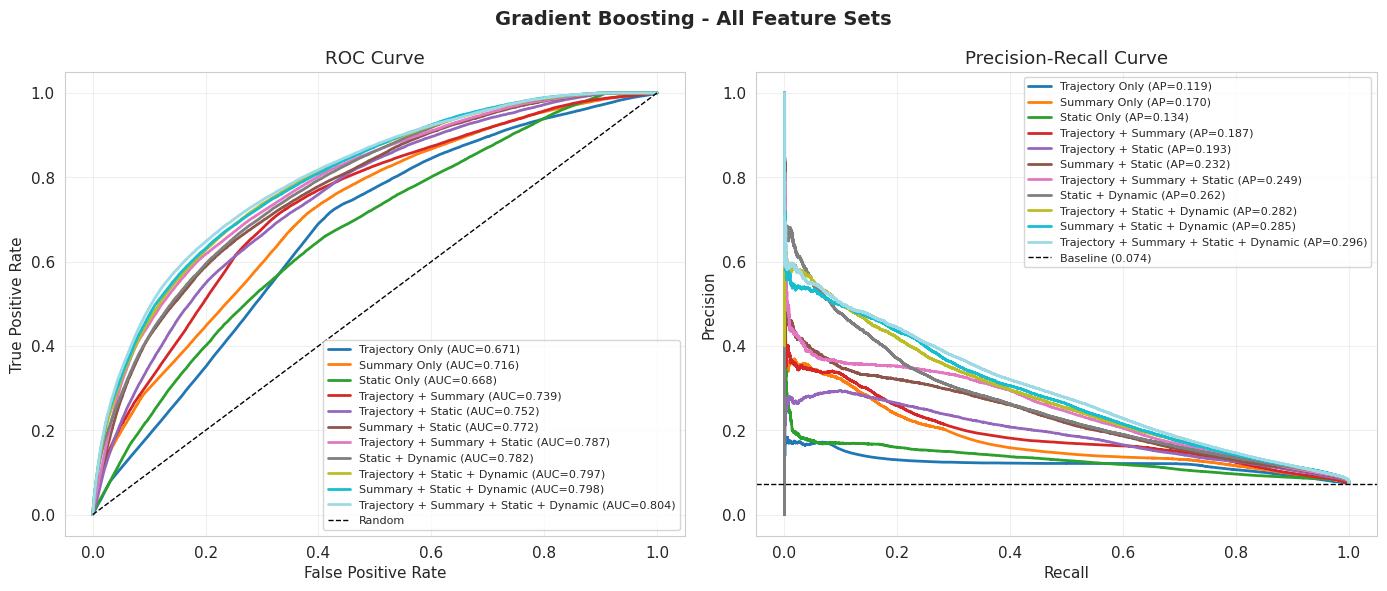

In [12]:
# ROC and PR curves for each model
for model_name in models_to_evaluate.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'{model_name} - All Feature Sets', fontsize=14, fontweight='bold')
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(results[model_name])))
    
    for idx, (name, metrics) in enumerate(results[model_name].items()):
        # ROC curve
        fpr, tpr, _ = roc_curve(metrics['y_true'], metrics['y_pred'])
        auc = np.mean(metrics['roc_auc'])
        ax1.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colors[idx], linewidth=2)
        
        # PR curve
        precision, recall, _ = precision_recall_curve(metrics['y_true'], metrics['y_pred'])
        ap = np.mean(metrics['avg_precision'])
        ax2.plot(recall, precision, label=f'{name} (AP={ap:.3f})', color=colors[idx], linewidth=2)
    
    # ROC plot formatting
    ax1.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve')
    ax1.legend(loc='lower right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # PR plot formatting
    baseline = y.mean()
    ax2.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline ({baseline:.3f})', linewidth=1)
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [13]:
# Model Comparison Summary
print("Model Comparison Across All Feature Sets:")
print("="*80)

summary_data = []
for model_name in models_to_evaluate.keys():
    for feature_set_name, metrics in results[model_name].items():
        summary_data.append({
            'Model': model_name,
            'Feature Set': feature_set_name,
            'AUROC': np.mean(metrics['roc_auc']),
            'AUROC_std': np.std(metrics['roc_auc']),
            'AUPR': np.mean(metrics['avg_precision']),
            'AUPR_std': np.std(metrics['avg_precision'])
        })

summary_df = pd.DataFrame(summary_data)

# Show best performing configurations
print("\nTop 10 Configurations by AUROC:")
print(summary_df.nlargest(10, 'AUROC')[['Model', 'Feature Set', 'AUROC', 'AUPR']].to_string(index=False))

print("\n" + "="*80)
print("Best Model Per Feature Set:")
for feature_set_name in feature_sets.keys():
    best = summary_df[summary_df['Feature Set'] == feature_set_name].nlargest(1, 'AUROC').iloc[0]
    print(f"  {feature_set_name:40s}: {best['Model']:20s} (AUROC={best['AUROC']:.3f}, AUPR={best['AUPR']:.3f})")

Model Comparison Across All Feature Sets:

Top 10 Configurations by AUROC:
            Model                             Feature Set    AUROC     AUPR
          XGBoost Trajectory + Summary + Static + Dynamic 0.804552 0.297223
Gradient Boosting Trajectory + Summary + Static + Dynamic 0.803886 0.295609
          XGBoost              Summary + Static + Dynamic 0.799841 0.286198
Gradient Boosting              Summary + Static + Dynamic 0.798148 0.285498
Gradient Boosting           Trajectory + Static + Dynamic 0.796638 0.282038
    Random Forest Trajectory + Summary + Static + Dynamic 0.796612 0.282243
          XGBoost           Trajectory + Static + Dynamic 0.796362 0.283715
          XGBoost           Trajectory + Summary + Static 0.787577 0.249551
    Random Forest           Trajectory + Static + Dynamic 0.787270 0.266870
Gradient Boosting           Trajectory + Summary + Static 0.786870 0.249270

Best Model Per Feature Set:
  Trajectory Only                         : Gradient Boostin

### Performance Summary

In [14]:
# Performance comparison table (per model)
print("\nPerformance Summary (per model):")
for model_name in models_to_evaluate.keys():
    print("\n" + model_name)
    print("-" * 60)
    summary_df = pd.DataFrame([
        {
            'Feature Set': name,
            'ROC-AUC': f"{np.mean(metrics['roc_auc']):.3f} ± {np.std(metrics['roc_auc']):.3f}",
            'AUPR': f"{np.mean(metrics['avg_precision']):.3f} ± {np.std(metrics['avg_precision']):.3f}"
        }
        for name, metrics in results[model_name].items()
    ])
    print(summary_df.to_string(index=False))


Performance Summary (per model):

XGBoost
------------------------------------------------------------
                            Feature Set       ROC-AUC          AUPR
                        Trajectory Only 0.671 ± 0.007 0.119 ± 0.005
                           Summary Only 0.716 ± 0.008 0.172 ± 0.010
                            Static Only 0.668 ± 0.011 0.134 ± 0.009
                   Trajectory + Summary 0.740 ± 0.008 0.187 ± 0.010
                    Trajectory + Static 0.752 ± 0.007 0.194 ± 0.016
                       Summary + Static 0.773 ± 0.010 0.232 ± 0.018
          Trajectory + Summary + Static 0.788 ± 0.008 0.250 ± 0.016
                       Static + Dynamic 0.783 ± 0.004 0.263 ± 0.012
          Trajectory + Static + Dynamic 0.796 ± 0.006 0.284 ± 0.015
             Summary + Static + Dynamic 0.800 ± 0.004 0.286 ± 0.010
Trajectory + Summary + Static + Dynamic 0.805 ± 0.006 0.297 ± 0.014

Logistic Regression
-----------------------------------------------------------

✓ Saved: ../../../results/eicu/ventilator/model_comparison_boxplots_xgboost.png


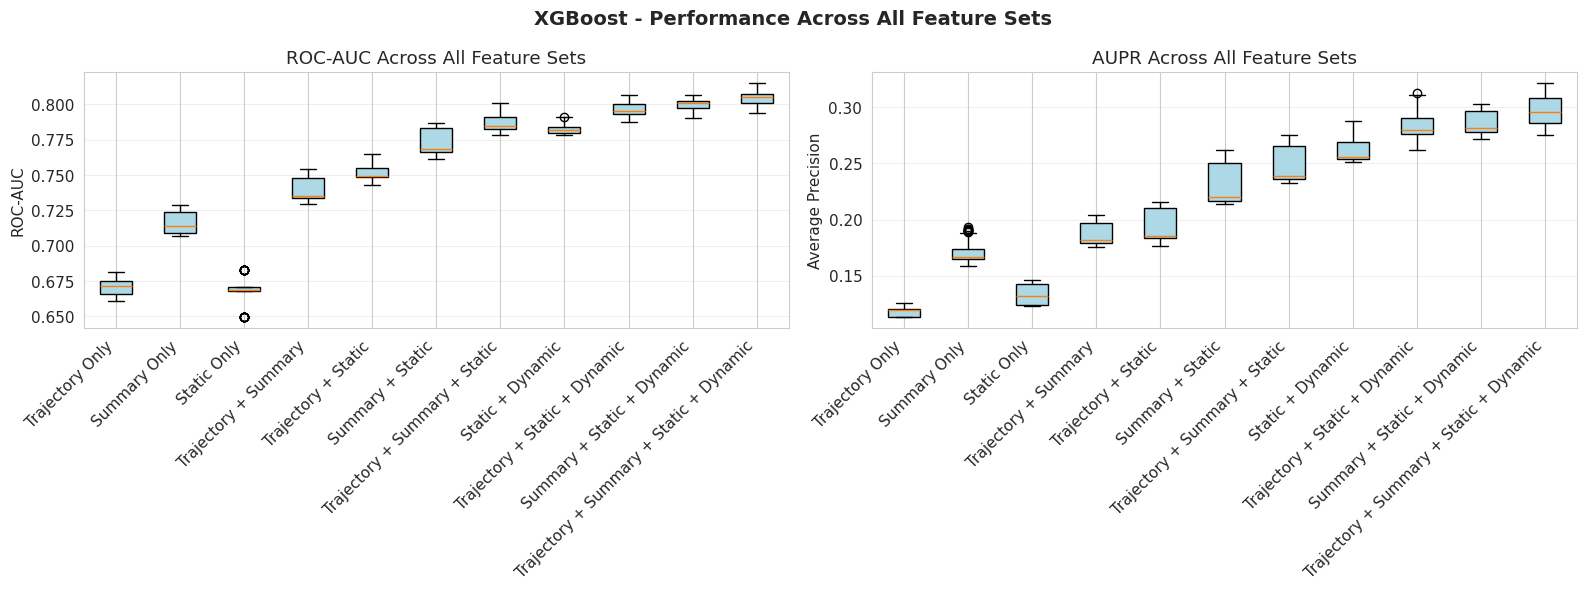

✓ Saved: ../../../results/eicu/ventilator/model_comparison_boxplots_logistic_regression.png


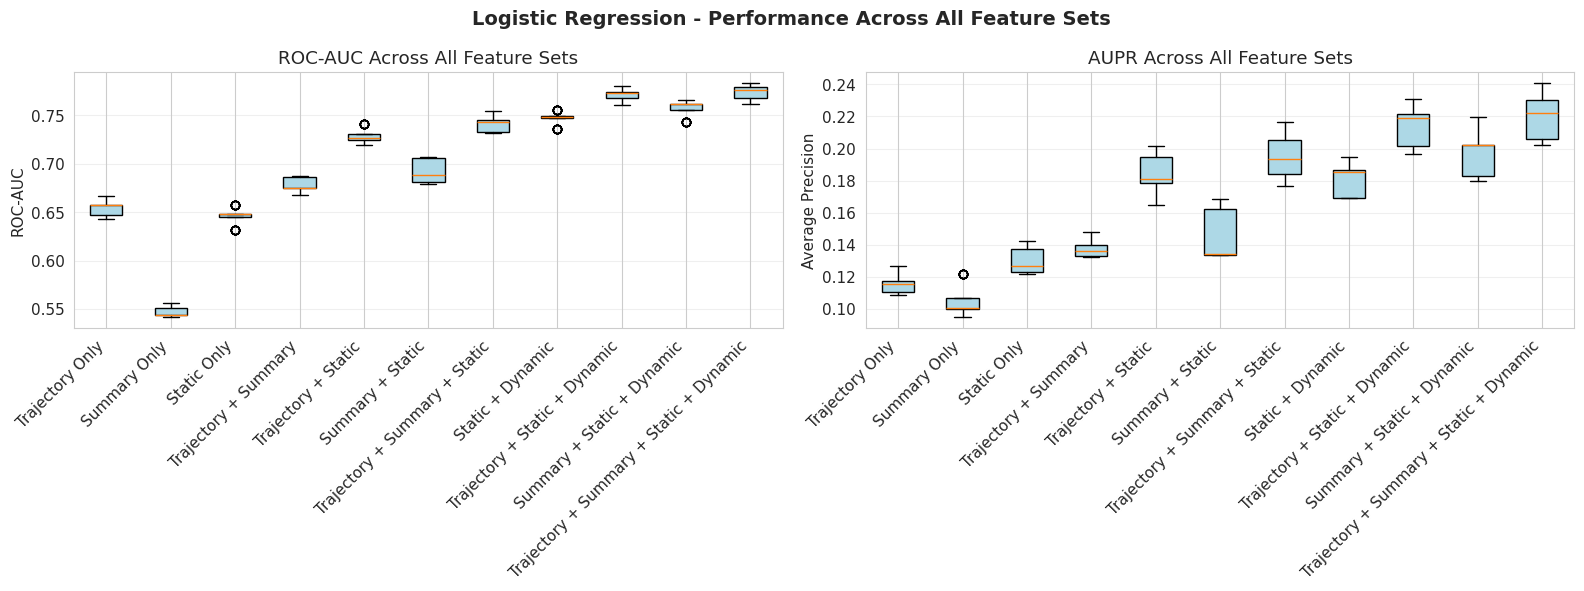

✓ Saved: ../../../results/eicu/ventilator/model_comparison_boxplots_random_forest.png


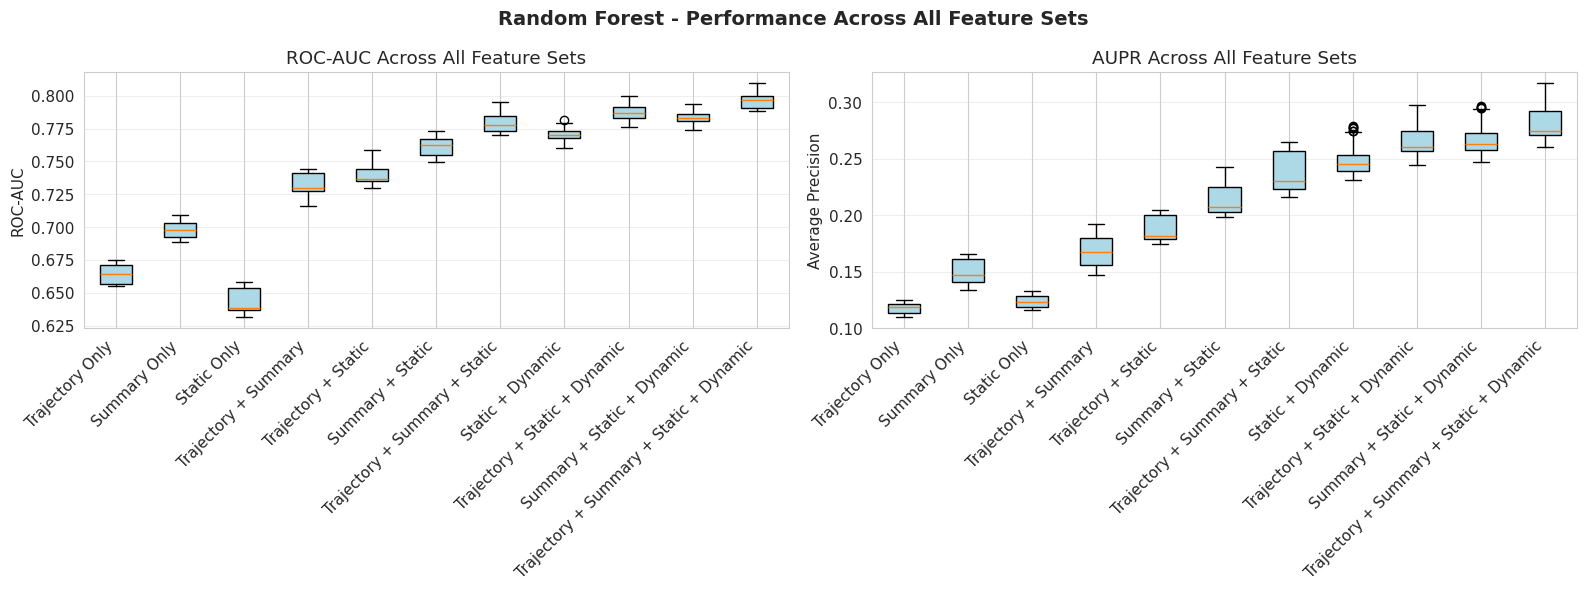

✓ Saved: ../../../results/eicu/ventilator/model_comparison_boxplots_gradient_boosting.png


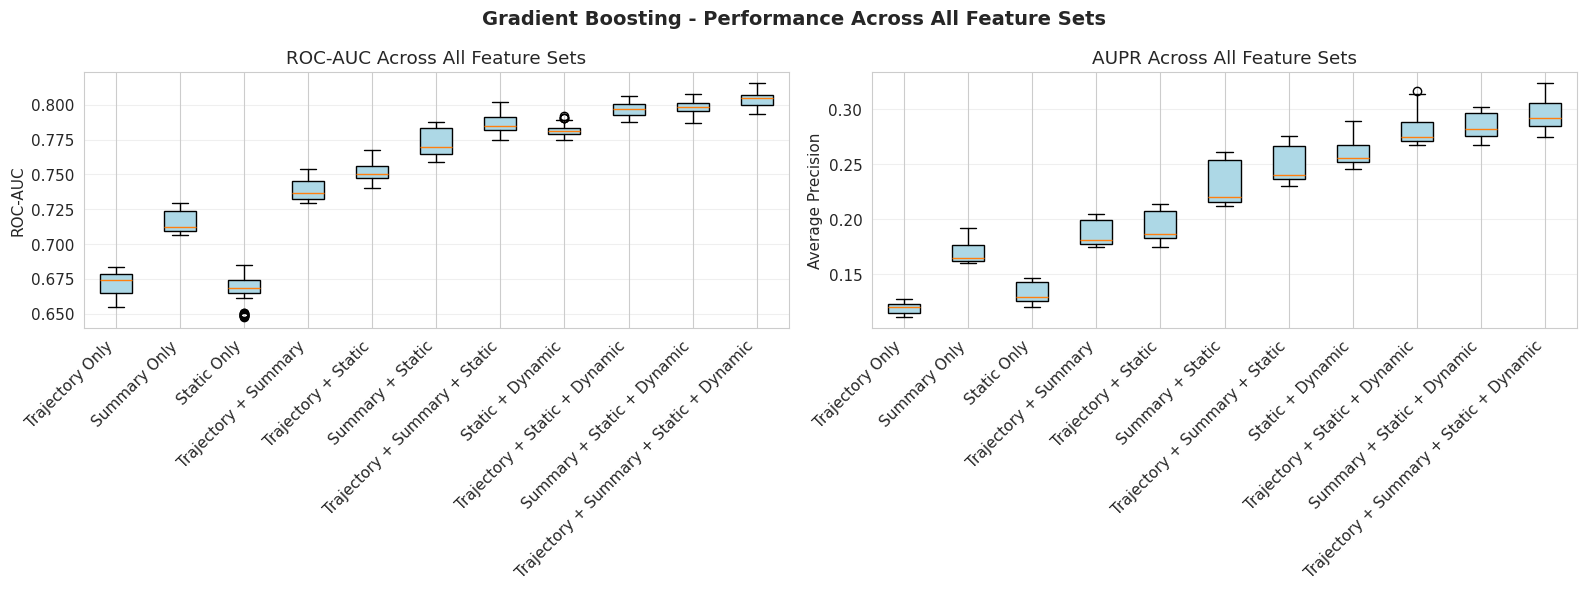

In [15]:
# Boxplots per model
for model_name in models_to_evaluate.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{model_name} - Performance Across All Feature Sets', fontsize=14, fontweight='bold')

    feature_set_names = list(results[model_name].keys())
    roc_data = [results[model_name][name]['roc_auc'] for name in feature_set_names]
    ap_data = [results[model_name][name]['avg_precision'] for name in feature_set_names]

    bp1 = ax1.boxplot(roc_data, labels=feature_set_names, patch_artist=True)
    ax1.set_ylabel('ROC-AUC')
    ax1.set_title('ROC-AUC Across All Feature Sets')
    ax1.set_xticklabels(feature_set_names, rotation=45, ha='right')
    ax1.grid(alpha=0.3, axis='y')

    bp2 = ax2.boxplot(ap_data, labels=feature_set_names, patch_artist=True)
    ax2.set_ylabel('Average Precision')
    ax2.set_title('AUPR Across All Feature Sets')
    ax2.set_xticklabels(feature_set_names, rotation=45, ha='right')
    ax2.grid(alpha=0.3, axis='y')

    for bp in [bp1, bp2]:
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')

    plt.tight_layout()
    outfile = f'../../../results/eicu/ventilator/model_comparison_boxplots_{model_name.replace(" ", "_").lower()}.png'
    plt.savefig(outfile, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {outfile}")
    plt.show()